In [93]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

In [94]:
#Load the dataset 
df=pd.read_excel("Telco_Customer_churn.xlsx")

In [95]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [96]:
#to chech rows and columns
df.shape

(7043, 33)

In [97]:
#check the datatypes 
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [98]:
#numerical summary
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [99]:
# missing values
df.isnull()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [100]:
#unique values
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [101]:
#complete information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [102]:
# duplicate rows 
df.duplicated().sum()

np.int64(0)

In [103]:
#missing values
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [104]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [105]:
churn_percentage=1869/7043*100
print(churn_percentage)

26.536987079369588


In [106]:
#target variable analysis
total_customers=df["Churn Label"].value_counts().sum()
print(total_customers)

7043


In [107]:
#check whether the churn is balanced 
df["Churn Label"].value_counts(normalize=True)* 100 

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [108]:
# percentage of customer who stayed
df["Churn Label"].value_counts()
stayed_customers=5174/7043*100
print(stayed_customers)

73.4630129206304


In [109]:
# percentage of customer who churned
df["Churn Label"].value_counts()
churned_customers=1869/7043*100
print(churned_customers)

26.536987079369588


In [110]:
#Identify important variable
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

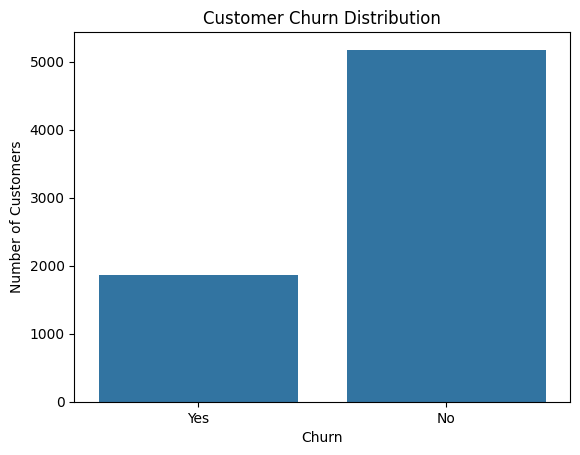

In [111]:
#Overall churn predictions
# how many customer stayed vs churned 
sns.countplot(data=df, x="Churn Label")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [112]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [113]:
df["Tenure Months"].max()

np.int64(72)

In [114]:
df["Tenure Months"].min()

np.int64(0)

In [115]:
df["Monthly Charges"].max()

np.float64(118.75)

In [116]:
df["Churn Score"].max()

np.int64(100)

In [117]:
#categorical value check 
df["Gender"].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [118]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [119]:
df['Internet Service'].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [120]:
df["Payment Method"].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [121]:
#DATA CLEANING (why there are only churn people left)
df[df["Churn Label"]=="No"] 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1869,7590-VHVEG,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.249020,Female,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,27,3964,NaN
1870,5575-GNVDE,1,United States,California,Los Angeles,90002,"33.949255, -118.246978",33.949255,-118.246978,Male,...,One year,No,Mailed check,56.95,1889.5,No,0,61,3441,NaN
1871,7795-CFOCW,1,United States,California,Los Angeles,90004,"34.076259, -118.310715",34.076259,-118.310715,Male,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,66,4307,NaN
1872,1452-KIOVK,1,United States,California,Los Angeles,90007,"34.027337, -118.28515",34.027337,-118.285150,Male,...,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,0,43,4459,NaN
1873,6713-OKOMC,1,United States,California,Los Angeles,90008,"34.008293, -118.346766",34.008293,-118.346766,Female,...,Month-to-month,No,Mailed check,29.75,301.9,No,0,51,2013,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [122]:
#in this we want to find the churn reason why people not left
df[df["Churn Label"]=="No"]["Churn Reason"].value_counts()


Series([], Name: count, dtype: int64)

In [123]:
df["Churn Reason"].isnull().sum()

np.int64(5174)

In [124]:
#replace value with new ones
df["Churn Reason"]=df["Churn Reason"].fillna("Not Churned")

In [125]:
df[df["Churn Label"]=="No"] 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1869,7590-VHVEG,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.249020,Female,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,27,3964,Not Churned
1870,5575-GNVDE,1,United States,California,Los Angeles,90002,"33.949255, -118.246978",33.949255,-118.246978,Male,...,One year,No,Mailed check,56.95,1889.5,No,0,61,3441,Not Churned
1871,7795-CFOCW,1,United States,California,Los Angeles,90004,"34.076259, -118.310715",34.076259,-118.310715,Male,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,66,4307,Not Churned
1872,1452-KIOVK,1,United States,California,Los Angeles,90007,"34.027337, -118.28515",34.027337,-118.285150,Male,...,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,0,43,4459,Not Churned
1873,6713-OKOMC,1,United States,California,Los Angeles,90008,"34.008293, -118.346766",34.008293,-118.346766,Female,...,Month-to-month,No,Mailed check,29.75,301.9,No,0,51,2013,Not Churned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,Not Churned
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,Not Churned
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,Not Churned
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,Not Churned


In [126]:
#Check the categorical columns
df["Gender"].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [128]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [129]:
df["Payment Method"].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [130]:
df["Churn Reason"].value_counts()

Churn Reason
Not Churned                                  5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Limited range of services                      44
Lack of affordable download/upload speed       44
Long distance charges                          44
Poor expertise of phone support                20
Poor expertise of online support     

In [131]:
#numerical data quality
df["Monthly Charges"].value_counts()

Monthly Charges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
43.05      1
72.00      1
108.35     1
63.10      1
78.70      1
Name: count, Length: 1585, dtype: int64

In [132]:
df["Monthly Charges"].mean()

np.float64(64.76169246059918)

In [133]:
df["Monthly Charges"].median()

np.float64(70.35)

In [134]:
df["Monthly Charges"].std() # it has low variability

np.float64(30.090047097678493)

In [135]:
#MONTHLY CHARGES VS CHURN
#do customers who churn pay higher charges than customer who stays?
#no(stayed) yes(churned)
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [136]:
# Tenure vs churn
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

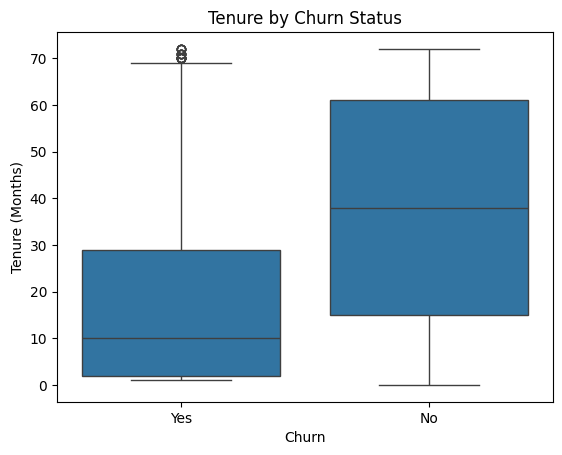

In [137]:
#Tenure vs churn

sns.boxplot(data=df, x="Churn Label", y="Tenure Months")
plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [138]:
df.groupby("Contract")["Churn Label"].value_counts()

Contract        Churn Label
Month-to-month  No             2220
                Yes            1655
One year        No             1307
                Yes             166
Two year        No             1647
                Yes              48
Name: count, dtype: int64

In [139]:
df["Contract"].value_counts()
month_to_month_contract=1655/3875*100
print(month_to_month_contract)
two_year=48/1695*100
print(two_year)
one_year=166/1473*100
print(one_year)

42.70967741935484
2.831858407079646
11.269517990495586


In [140]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

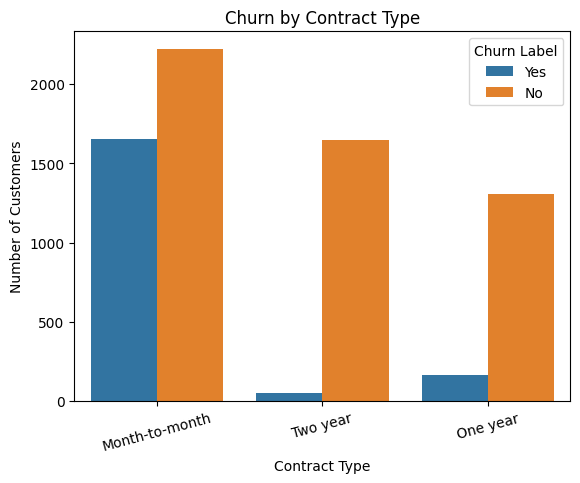

In [141]:
#Churn by contract
sns.countplot(data=df, x="Contract", hue="Churn Label")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [142]:
# Payment method 
# which payment method  has highest churn percentage 
df.groupby("Payment Method")['Churn Label'].value_counts()

Payment Method             Churn Label
Bank transfer (automatic)  No             1286
                           Yes             258
Credit card (automatic)    No             1290
                           Yes             232
Electronic check           No             1294
                           Yes            1071
Mailed check               No             1304
                           Yes             308
Name: count, dtype: int64

In [143]:
#replace values  of no and yes with churned and stayed 
df["Churn Label"]=df["Churn Label"].replace({
    "No":"Stayed",
    "Yes":"Churned"
})

In [144]:
# which payment method  has highest churn percentage 
df["Payment Method"].value_counts()
automatic =258/1544*100
print(automatic)
credit_card=232/1522*100
print(credit_card)
electronic_check=1071/2365*100
print(electronic_check)
mailed_check=308/1612*100
print(mailed_check)

16.709844559585495
15.243101182654403
45.28541226215645
19.106699751861044


In [145]:
df["Payment Method"].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [146]:
#internet services (find patterns)
#which internet service has the highest churn percentage 
df.groupby("Internet Service")["Churn Label"].value_counts()

Internet Service  Churn Label
DSL               Stayed         1962
                  Churned         459
Fiber optic       Stayed         1799
                  Churned        1297
No                Stayed         1413
                  Churned         113
Name: count, dtype: int64

In [147]:
df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [148]:
#percentage  of churned customer per internet service
dsl=459/2421*100
print(dsl)
fiber_optics=1297/3096*100
print(fiber_optics)
no=113/1526*100
print(no)

18.95910780669145
41.89276485788114
7.404980340760157


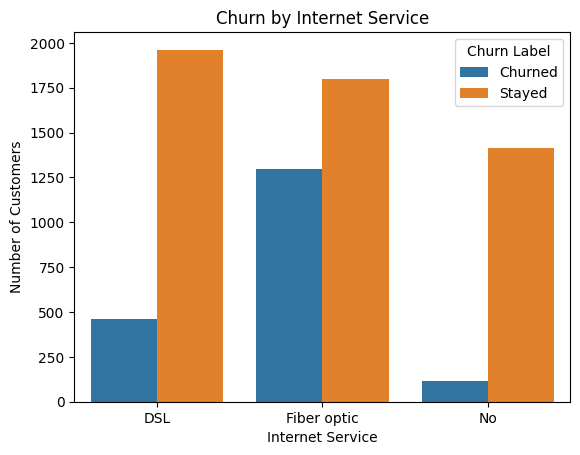

In [149]:
#Churned By internet service
sns.countplot(data=df, x="Internet Service", hue="Churn Label")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [150]:
#important categorical variables
#tech vs churn(find possible churn factors)
df["Tech Support"].value_counts()

Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [151]:
df.groupby("Tech Support")["Churn Label"].value_counts()

Tech Support         Churn Label
No                   Stayed         2027
                     Churned        1446
No internet service  Stayed         1413
                     Churned         113
Yes                  Stayed         1734
                     Churned         310
Name: count, dtype: int64

In [152]:
#do customers who have tech support has lower churn
no=1466/3473*100
print(no)
no_internet_service=113/1526*100
print(no_internet_service)
yes=310/2044*100
print(yes)

42.21134465879643
7.404980340760157
15.166340508806261


In [153]:
# online security
df["Online Security"].value_counts()

Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [154]:
df.groupby("Online Security")["Churn Label"].value_counts()

Online Security      Churn Label
No                   Stayed         2037
                     Churned        1461
No internet service  Stayed         1413
                     Churned         113
Yes                  Stayed         1724
                     Churned         295
Name: count, dtype: int64

In [155]:
#do customers who have online security has lower churn
no=1461/3498*100
print(no)
no_internet_service=113/1526*100
print(no_internet_service)
yes=295/2019*100
print(yes)

41.76672384219554
7.404980340760157
14.611193660227837


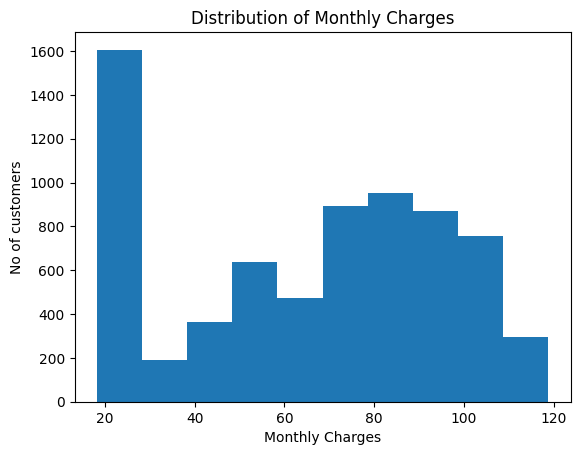

In [156]:
#MONTHLY CHARGES DISTRIBUTIONS
# how are customers monthly charges districuted
plt.hist(df["Monthly Charges"])
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("No of customers")
plt.show()

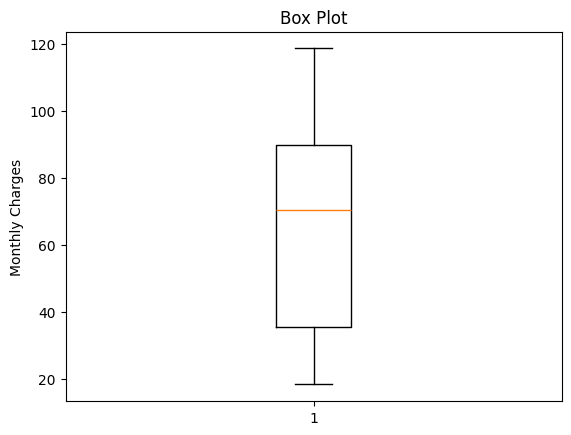

In [157]:
#box plot 
#are there unusual monthly charges values?
plt.boxplot(df["Monthly Charges"])
plt.title("Box Plot")
plt.ylabel("Monthly Charges")
plt.show()

In [158]:
# calculate the correlation matrix
df.corr(numeric_only=True)

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,-0.127463,-0.079782,1.000000


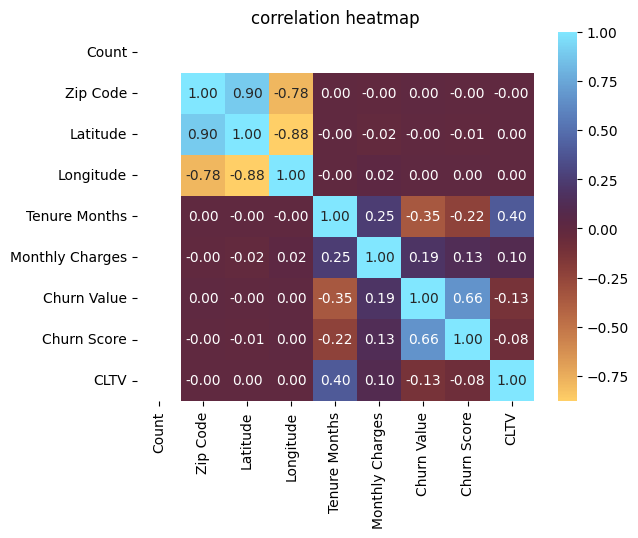

In [159]:
sns.heatmap(df.corr(numeric_only=True),cmap='managua',annot=True,fmt=".2f")
plt.title("correlation heatmap")
plt.show()

In [160]:
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

Churned customers have much shorter tenure
Stayed: ~37.57 months
Churned: ~17.98 months
→ Customers with shorter tenure are associated with higher churn.
Churned customers have higher average Monthly Charges
Stayed: ~61.27
Churned: ~74.44
→ Higher monthly charges are associated with higher churn.
Contract type is strongly associated with churn
Month-to-month: 42.71% churn
One year: 11.27%
Two year: 2.83% → Month-to-month customers are much more likely to churn.
Payment method shows different churn levels
→ Some payment methods have considerably higher churn than others.
Internet Service types show different churn patterns
→ Churn varies depending on the internet service type.
Tech Support and Online Security are useful churn-related categories
→ Their churn percentages differ between customers who have and don't have these services.
Monthly Charges have a non-uniform distribution
Your histogram showed a strong concentration at lower charges and a long higher-charge side.
Tenure and Churn Value have a negative correlation (~−0.35)
→ Longer-tenure customers tend to have lower churn.
Churn Value and Churn Score have a strong positive correlation (~0.665)
→ Customers with higher churn values tend to have higher churn scores.


In [161]:
df["Monthly Charges"].var()

np.float64(905.4109343405098)

In [162]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Churned,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Churned,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Churned,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Churned,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Churned,1,89,5340,Competitor had better devices


In [163]:
df["Monthly Charges"].quantile([0.25,0.50,0.75])

0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charges, dtype: float64

In [164]:
#percentiles to understand customer positions 
#quartiles divide customers into groups
#iqr = identify the outliers
## Lets find outliers using iqr 
Q1=df["Monthly Charges"].quantile(0.25)
Q3=df["Monthly Charges"].quantile(0.75)

In [165]:
IQR=Q3-Q1

In [166]:
lower_boundary=Q1-1.5*IQR
upper_boundary=Q3-1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("lower_boundary:",lower_boundary)
print("upper_boundary:",upper_boundary)

Q1: 35.5
Q3: 89.85
lower_boundary: -46.02499999999999
upper_boundary: 8.325000000000003


In [167]:
outliers=df[(df["Monthly Charges"]<lower_boundary)| (df["Monthly Charges"]>upper_boundary)]

In [168]:
outliers.shape[0]

7043

In [169]:
outliers["Monthly Charges"]

0        53.85
1        70.70
2        99.65
3       104.80
4       103.70
         ...  
7038     21.15
7039     84.80
7040    103.20
7041     29.60
7042    105.65
Name: Monthly Charges, Length: 7043, dtype: float64

In [170]:
df["Monthly Charges"].skew()

np.float64(-0.22052443394398033)

In [171]:
df["Churn Label"].value_counts()

Churn Label
Stayed     5174
Churned    1869
Name: count, dtype: int64

In [172]:
df["Churn Label"].unique()

<StringArray>
['Churned', 'Stayed']
Length: 2, dtype: str

In [173]:
y=df["Churn Label"]

In [174]:
# started feature preparation
X=df.drop("Churn Label",axis=1)

In [175]:
print(X.shape)
print(y.shape)

(7043, 32)
(7043,)


In [176]:
X.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices


In [177]:
y.head()

0    Churned
1    Churned
2    Churned
3    Churned
4    Churned
Name: Churn Label, dtype: str

In [178]:
X.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [179]:
drop_cols=["CustomerID","Count","Churn Value","Churn Score","Churn Reason","Churn Category"]
X=X.drop(columns=drop_cols,errors="ignore")

In [180]:
X.columns.tolist()

['Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'CLTV']

In [181]:
X.dtypes

Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
CLTV                   int64
dtype: object

In [182]:
#just created seperate list for better understanding
numerical_features=X.select_dtypes(include="number").columns
categorical_features=X.select_dtypes(exclude="number").columns

In [183]:
print("Numerical:",numerical_features.tolist())
print("Categorical:",categorical_features.tolist())

Numerical: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'CLTV']
Categorical: ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']


In [184]:
X["Total Charges"]=pd.to_numeric(X["Total Charges"],errors ="coerce")

In [185]:
X=X.drop(columns=["City","State","Country","Zip Code","Latitude","Longitude","Lat Long"],errors="ignore")

In [186]:
#just created seperate list for better understanding
numerical_features=X.select_dtypes(include="number").columns
categorical_features=X.select_dtypes(exclude="number").columns

In [187]:
print("Numerical:",numerical_features.tolist())
print("Categorical:",categorical_features.tolist())

Numerical: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [188]:
X_encoded=pd.get_dummies(X,columns=categorical_features,drop_first=True)

In [189]:
X_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,3239,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,2701,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,5372,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,5003,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,5340,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [190]:
X_encoded.shape

(7043, 31)

In [191]:
X_encoded.dtypes.value_counts()

bool       27
int64       2
float64     2
Name: count, dtype: int64

In [192]:
y=y.map({
    "Stayed":0,
    "Churned":1
})

In [193]:
y.value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [194]:
print(sklearn.__version__)

1.7.2


In [207]:
from sklearn.model_selection import train_test_split

In [208]:
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42,stratify=y)

In [209]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 31)
(1409, 31)
(5634,)
(1409,)


In [210]:
#MODEL BUILDING
# step1: Import logistic regression
from sklearn.linear_model import LogisticRegression

In [211]:
#to check missing values 
X_train.isna().sum().sum()

np.int64(8)

In [212]:
# to fill the missing value
X_train=X_train.fillna(X_train.median(numeric_only=True))

In [213]:
#to fill the testing values 
X_test=X_test.fillna(X_train.median(numeric_only=True))

In [216]:
from sklearn.preprocessing import StandardScaler 
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [217]:
#create model
model=LogisticRegression(max_iter=5000)

In [218]:
#train it 
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [219]:
# make predictions
y_pred=model.predict(X_test_scaled)

In [220]:
print(y_pred[:10])

[0 1 0 0 0 1 0 0 0 0]


In [221]:
#to check actual result(y_test) vs model prediction(y_pred)
from sklearn.metrics import confusion_matrix

In [222]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[915 120]
 [160 214]]


In [223]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [224]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.801277501774308
Precision: 0.6407185628742516
Recall: 0.5721925133689839
F1 Score: 0.6045197740112994


In [225]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8485520163269523


In [226]:
#predic_proba()
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [227]:
#Random Forest 
from sklearn.ensemble import RandomForestClassifier

In [228]:
#create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [229]:
#train it 
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [230]:
#predict it
rf_pred = rf_model.predict(X_test)

In [231]:
# Evaluate the random forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [232]:
#basic metrics
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.794889992902768
Precision: 0.6430976430976431
Recall: 0.5106951871657754
F1 Score: 0.5692995529061102


In [233]:
#ROC-AUC
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.8366000155002713


In [234]:
#Compare the models
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801278,0.640719,0.572193,0.60452,0.848552
1,Random Forest,0.794890,0.643098,0.510695,0.56930,0.836600


In [235]:
#Feature Importance
#Which customer features were most useful to the random forests when making churn predictions 
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Total Charges,0.153795
0,Tenure Months,0.153083
1,Monthly Charges,0.133425
3,CLTV,0.124048
11,Internet Service_Fiber optic,0.040295
7,Dependents_Yes,0.035682
29,Payment Method_Electronic check,0.035204
26,Contract_Two year,0.031946
4,Gender_Male,0.022904
14,Online Security_Yes,0.022694


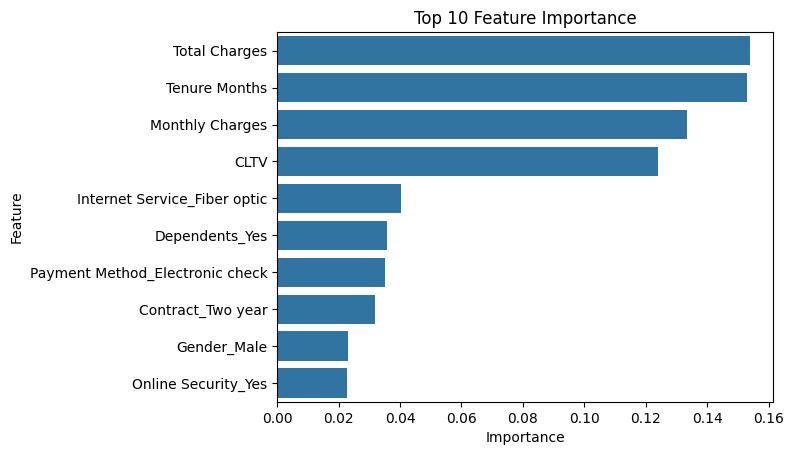

In [236]:
#Feature importance chart 

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [237]:

df.groupby("Contract")["Churn Label"].value_counts(normalize=True)

Contract        Churn Label
Month-to-month  Stayed         0.572903
                Churned        0.427097
One year        Stayed         0.887305
                Churned        0.112695
Two year        Stayed         0.971681
                Churned        0.028319
Name: proportion, dtype: float64

In [238]:
# Churn by contract
analysis_df=X.copy()
analysis_df["Churn Label"]=y

In [239]:
analysis_df.groupby("Contract")["Churn Label"].value_counts(normalize=True)

Contract        Churn Label
Month-to-month  0              0.572903
                1              0.427097
One year        0              0.887305
                1              0.112695
Two year        0              0.971681
                1              0.028319
Name: proportion, dtype: float64

# Business Insights
1-Tenure Months is one of the most important predictive features, indicating that customer tenure is strongly useful for identifying potential churn.
2-Monthly Charges and Total Charges are also among the strongest predictive features, suggesting that customer billing characteristics are important when predicting churn.
3-CLTV (Customer Lifetime Value) is another important feature used by the model for churn prediction.
4-Internet Service – Fiber optic appears among the important categorical predictors.
5-The Logistic Regression model performed better than Random Forest on this dataset, with 80.1% accuracy and 0.849 ROC-AUC.

# CONCLUSION

This project analyzed customer churn using Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn. The analysis included data cleaning, exploratory data analysis, statistical analysis, and basic machine learning. Logistic Regression and Random Forest were used for churn prediction, with Logistic Regression performing better on the test data with 80.1% accuracy and 0.849 ROC-AUC. The analysis identified important predictive features such as Total Charges, Tenure Months, Monthly Charges, and CLTV, providing useful insights for targeted customer retention strategies